<a href="https://colab.research.google.com/github/JosNavarro/Invest2026-27/blob/main/GRUVanilla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import h5py
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import gc

from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/B0006train.mat'
batt_train_id = 'B0006'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
def graficar_modelo(actual, predicted, battery_id, r2_score):
    """
    Genera la gráfica de degradación con fondo blanco y estilo clásico,
    exactamente igual a la imagen de referencia.
    """
    # Usar el mismo tamaño ancho que en tu imagen
    fig, ax = plt.subplots(figsize=(12, 7))

    # Fondo blanco
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Curvas de datos: Azul (Real) y Rojo (Predicción)
    ax.plot(actual, label=f'Actual Capacity (NASA {battery_id})', color='blue', linewidth=2)
    ax.plot(predicted, label='GRU Predicted Capacity', color='red', linewidth=2)

    # Umbral de Fin de Vida (Línea punteada negra)
    ax.axhline(y=1.4, color='black', linestyle=':', label='End of Life Threshold (1.4 Ah)')

    # Título y etiquetas con texto en negro
    ax.set_title(f'Battery Degradation: Actual vs. GRU Prediction ($R^2$: {r2_score:.4f})', color='black', fontsize=13)
    ax.set_xlabel('Cycles (Sliding Windows)', color='black', fontsize=11)
    ax.set_ylabel('Capacity (Ah)', color='black', fontsize=11)

    # Configuración de ejes
    ax.tick_params(colors='black')

    # Leyenda en la esquina superior derecha con fondo blanco
    ax.legend(facecolor='white', edgecolor='lightgray', labelcolor='black', loc='upper right')

    # Cuadrícula: Líneas punteadas grises
    ax.grid(True, linestyle='--', color='silver', alpha=0.8)

    # Bordes del gráfico en negro
    for spine in ax.spines.values():
        spine.set_edgecolor('black')

    plt.tight_layout()
    plt.show()

In [3]:
with h5py.File(data_path, 'r') as f:
  X_raw = np.array(f['X_3D'])
  cap_min = np.array(f['cap_min']).item()
  cap_max = np.array(f['cap_max']).item()

In [4]:
# h5py reads it as [features, window_size, windows]
# We transpose it back to [windows, window_size, features] -> (2, 1, 0)
X_corrected = np.transpose(X_raw, (2, 1, 0))
print(f"Corrected Tensor shape: {X_corrected.shape}")

Corrected Tensor shape: (50236, 50, 8)


In [17]:
X_train_data = X_corrected[:, :, :7]
Y_train_data = X_corrected[:, -1, 7]
X_train_tensor = torch.tensor(X_train_data, dtype=torch.float32)

In [18]:

Y_tensor = torch.tensor(Y_train_data, dtype=torch.float32).unsqueeze(1)


In [19]:
dataset = TensorDataset(X_tensor, Y_tensor)

# Power of 2 are standard
batch_size = 32


train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [20]:
import torch.nn as nn

class BatteryRULPredictor(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, output_size=1):
        """
        Initializes the GRU model.

        Args:
            input_size (int): Number of features per time step (8 in our NASA data).
            hidden_size (int): The number of features in the hidden state (the "memory" size).
            num_layers (int): Number of stacked GRU layers.
            output_size (int): Number of predicted values (1 for Capacity).
        """
        super(BatteryRULPredictor, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # 1. The GRU Layer
        # batch_first=True is CRITICAL because our DataLoader outputs
        # tensors in the shape [batch_size, window_size, input_size]
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0 # Adds dropout for regularization if stacked
        )

        # 2. The Fully Connected (Linear) Layer
        # This takes the final hidden state of the GRU and condenses it down to our 1 output
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """
        Defines the forward pass of the data through the network.

        Args:
            x (Tensor): Input tensor of shape [batch_size, window_size, features]
        """
        # Pass the input sequence through the GRU
        # 'out' contains the output features from the last layer of the GRU for each time step
        # 'h_n' contains the final hidden state
        out, h_n = self.gru(x)

        # We only care about the GRU's output at the very LAST time step of the window
        # out shape is [batch_size, window_size, hidden_size]
        # out[:, -1, :] grabs the final time step across the entire batch
        last_time_step_out = out[:, -1, :]

        # Pass that final time step's output through the linear layer to get the prediction
        prediction = self.fc(last_time_step_out)

        return prediction

# Instantiate the model
# We use 8 for input_size since we extracted exactly 8 features
model = BatteryRULPredictor(input_size=7, hidden_size=64, num_layers=2, output_size=1)

print("GRU Model Architecture defined successfully!")
print(model)

GRU Model Architecture defined successfully!
BatteryRULPredictor(
  (gru): GRU(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [21]:
# ==========================================
# 1. Setup: Device, Loss, and Optimizer
# ==========================================
# Check if a GPU is available (highly recommended for Colab)
# Go to Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Move the model to the chosen device
model.to(device)

# Define the Loss Function
criterion = nn.MSELoss()

# Define the Optimizer
# The learning rate (lr) dictates how big of a step the model takes when adjusting weights
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training on device: cuda


In [22]:
num_epochs = 50 # Number of times to loop through the entire dataset

# Set the model to training mode (enables dropout, etc.)
model.train()

print("Starting training...")

for epoch in range(num_epochs):
    epoch_loss = 0.0

    # Loop through the batches in our DataLoader
    for batch_X, batch_Y in train_loader:
        # Move the batch data to the same device as the model
        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)

        # Step 1: Clear the old gradients from the last step
        optimizer.zero_grad()

        # Step 2: Forward pass (the model makes its predictions)
        predictions = model(batch_X)

        # Step 3: Calculate the error (compare predictions to the actual targets)
        loss = criterion(predictions, batch_Y)

        # Step 4: Backward pass (calculate the math needed to correct the error)
        loss.backward()

        # Step 5: Update the model's weights based on the backward pass
        optimizer.step()

        # Add up the loss to track progress
        epoch_loss += loss.item()

    # Calculate the average loss across all batches for this epoch
    avg_epoch_loss = epoch_loss / len(train_loader)

    # Print the progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss (MSE): {avg_epoch_loss:.6f}')

print("Training complete!")

Starting training...
Epoch [1/50], Average Loss (MSE): 0.003087
Epoch [10/50], Average Loss (MSE): 0.000479
Epoch [20/50], Average Loss (MSE): 0.000317
Epoch [30/50], Average Loss (MSE): 0.000250
Epoch [40/50], Average Loss (MSE): 0.000231
Epoch [50/50], Average Loss (MSE): 0.000225
Training complete!


In [23]:
# ==========================================
# 3. Generate Predictions (OOM Safe)
# ==========================================
# Limpiar memoria de la GPU
torch.cuda.empty_cache()
gc.collect()

print(f"Generando predicciones finales sobre los datos de entrenamiento ({batt_train_id})...")
model.eval()
all_train_predictions = []
batch_size = 256 # Tamaño de bocado seguro
num_train_samples = X_train_tensor.shape[0]

with torch.no_grad():
    for i in range(0, num_train_samples, batch_size):
        batch_X = X_train_tensor[i : i + batch_size].to(device)
        batch_preds = model(batch_X)
        all_train_predictions.append(batch_preds.cpu().numpy())

# Unir todos los lotes
train_preds_numpy = np.concatenate(all_train_predictions, axis=0)

Generando predicciones finales sobre los datos de entrenamiento (B0006)...


In [24]:
# ==========================================
# 4. Un-normalize the Data
# ==========================================
# Regresar los valores de la escala 0-1 a la escala real (Amperios-hora)
actual_train_capacity = (Y_train_data * (cap_max - cap_min)) + cap_min
predicted_train_capacity = (train_preds_numpy.flatten() * (cap_max - cap_min)) + cap_min

In [25]:
# ==========================================
# 5. Calculate Error Metrics
# ==========================================
train_mse = mean_squared_error(actual_train_capacity, predicted_train_capacity)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(actual_train_capacity, predicted_train_capacity)
train_r2 = r2_score(actual_train_capacity, predicted_train_capacity)

# Imprimir el reporte
print("-" * 40)
print(f"REPORTE DE RENDIMIENTO: Batería {batt_train_id} (ENTRENAMIENTO)")
print("-" * 40)
print(f"MSE  (Mean Squared Error):      {train_mse:.6f}")
print(f"RMSE (Root Mean Squared Error): {train_rmse:.6f} Ah")
print(f"MAE  (Mean Absolute Error):     {train_mae:.6f} Ah")
print(f"R^2  (R-Squared):               {train_r2:.4f}")
print("-" * 40)

----------------------------------------
REPORTE DE RENDIMIENTO: Batería B0006 (ENTRENAMIENTO)
----------------------------------------
MSE  (Mean Squared Error):      0.000187
RMSE (Root Mean Squared Error): 0.013666 Ah
MAE  (Mean Absolute Error):     0.009265 Ah
R^2  (R-Squared):               0.9966
----------------------------------------


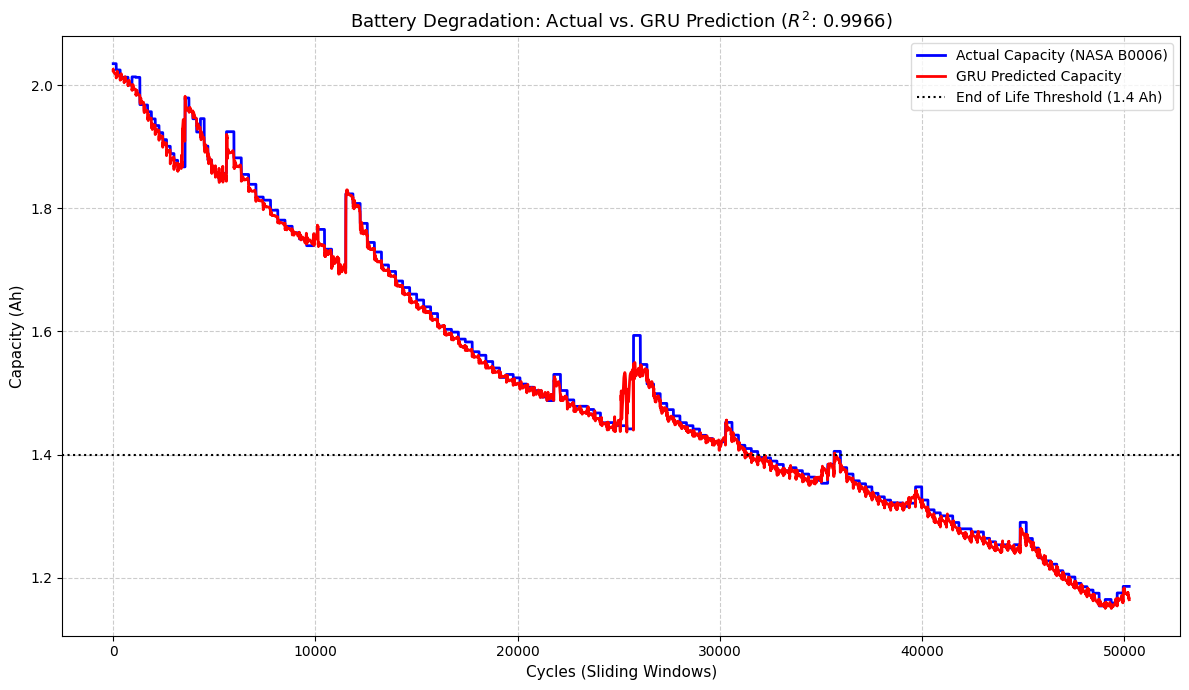

In [26]:
# ==========================================
# 4. Plot the Results
# ==========================================
# Llamada a la función maestra (asegúrate de haber ejecutado la celda con la función 'graficar_modelo' antes)
graficar_modelo(actual_train_capacity, predicted_train_capacity, batt_train_id, train_r2)

# Evaluation with other datasets


In [27]:
# ==========================================
# 1. Load the Test Data
# ==========================================
test_file_path = '/content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/B0007test.mat' # Update path if necessary

with h5py.File(test_file_path, 'r') as f:
    X_raw_test = np.array(f['X_3D'])
    # These are the B0005 scaling factors we successfully passed through!
    cap_min = np.array(f['cap_min']).item()
    cap_max = np.array(f['cap_max']).item()



In [28]:
# ==========================================
# 2. Transpose and Split
# ==========================================
# Fix the MATLAB (Fortran) to Python (C) orientation
X_corrected_test = np.transpose(X_raw_test, (2, 1, 0))
print(f"Test Tensor Shape: {X_corrected_test.shape}")

X_test_data = X_corrected_test[:, :, :7]
Y_test_data = X_corrected_test[:, -1, 7]

# Convert to PyTorch tensors
X_test_tensor = torch.tensor(X_test_data, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test_data, dtype=torch.float32).unsqueeze(1)


Test Tensor Shape: (50236, 50, 8)


In [29]:
# ==========================================
# 3. Run Inference (Testing) - VERSIÓN POR LOTES
# ==========================================
print("Running GRU model on test data...")

# Limpiar la memoria basura que dejó el choque anterior en la tarjeta gráfica
import gc
torch.cuda.empty_cache()
gc.collect()

model.eval()

# Lista para guardar los pedacitos de las predicciones
all_predictions = []

# Tamaño del bocado (Si te vuelve a dar OOM, baja este número a 128 o 64)
batch_size = 256
num_samples = X_test_tensor.shape[0]

with torch.no_grad():
    # Bucle para procesar los datos en pequeños lotes
    for i in range(0, num_samples, batch_size):
        # Extraer el lote actual
        batch_X = X_test_tensor[i : i + batch_size].to(device)

        # Hacer la predicción solo de este lote
        batch_preds_scaled = model(batch_X)

        # Mover la predicción de vuelta a la memoria normal (CPU) inmediatamente
        # para liberar espacio en la GPU, y guardarla en la lista
        all_predictions.append(batch_preds_scaled.cpu().numpy())

# Unir todos los pedacitos de vuelta en un solo arreglo gigante
test_preds_numpy = np.concatenate(all_predictions, axis=0)

print("¡Inferencia completada sin desbordar la memoria!")

Running GRU model on test data...
¡Inferencia completada sin desbordar la memoria!


In [30]:
# ==========================================
# 4. Un-normalize the Data
# ==========================================
# Convert from 0-to-1 scale back to real Ampere-hours (Ah)
actual_test_capacity = (Y_test_data * (cap_max - cap_min)) + cap_min
predicted_test_capacity = (test_preds_numpy.flatten() * (cap_max - cap_min)) + cap_min

----------------------------------------
REPORTE DE RENDIMIENTO: Batería B0007 (Testing)
----------------------------------------
MSE  (Mean Squared Error):      0.010742
RMSE (Root Mean Squared Error): 0.103644 Ah
MAE  (Mean Absolute Error):     0.091268 Ah
R^2  (R-Squared):               0.5388
----------------------------------------


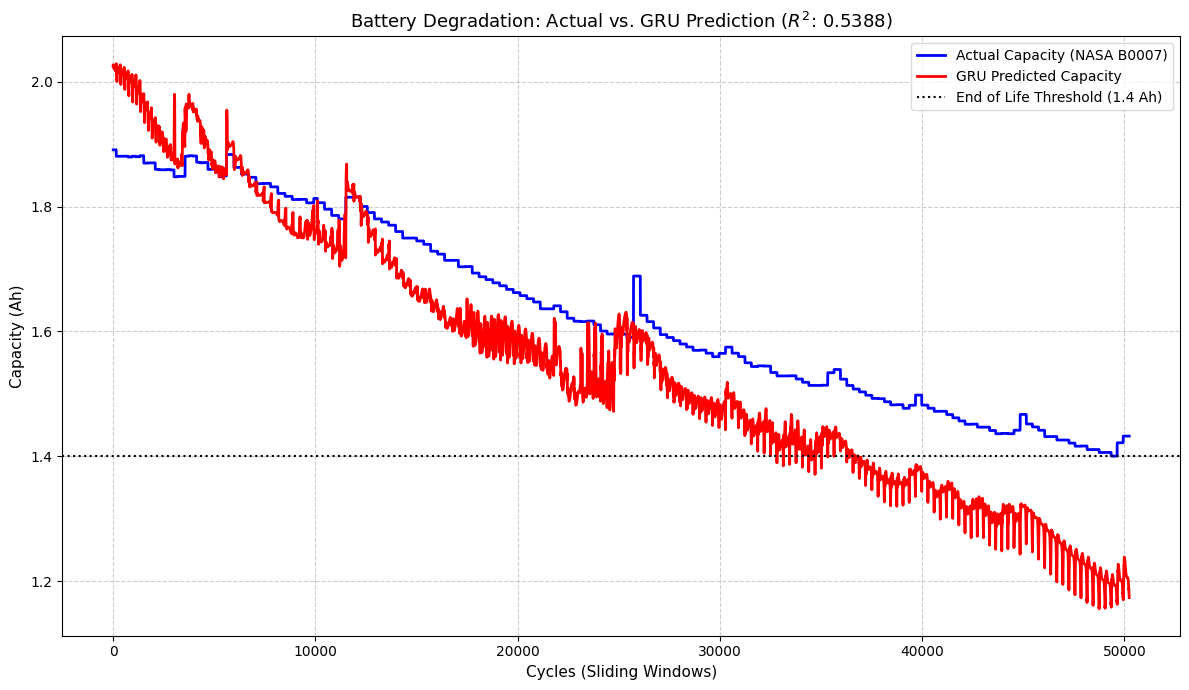

In [32]:
# ==========================================
# CONFIGURACIÓN INICIAL
# ==========================================
battery_id = 'B0007'

# ==========================================
# 5. Calculate Error, Metrics & Plot
# ==========================================

# 1. Calcular las métricas matemáticas
test_mse = mean_squared_error(actual_test_capacity, predicted_test_capacity)
test_rmse = np.sqrt(test_mse) # Raíz cuadrada del MSE
test_mae = mean_absolute_error(actual_test_capacity, predicted_test_capacity)
test_r2 = r2_score(actual_test_capacity, predicted_test_capacity)

# 2. Imprimir el reporte de rendimiento en la consola
print("-" * 40)
print(f"REPORTE DE RENDIMIENTO: Batería {battery_id} (Testing)")
print("-" * 40)
print(f"MSE  (Mean Squared Error):      {test_mse:.6f}")
print(f"RMSE (Root Mean Squared Error): {test_rmse:.6f} Ah")
print(f"MAE  (Mean Absolute Error):     {test_mae:.6f} Ah")
print(f"R^2  (R-Squared):               {test_r2:.4f}")
print("-" * 40)

graficar_modelo(actual_test_capacity, predicted_test_capacity, battery_id, test_r2)